Дані завантажено успішно
Train shape: (307511, 202)
X shape: (307511, 201)
Target distribution:
TARGET
0    0.919271
1    0.080729
Name: proportion, dtype: float64

Знайдені кандидати LightGBM:
C:\programas\diploma\data\notebooks\lightgbm_model.pkl | size: 389876596
C:\programas\diploma\data\notebooks\saved_models\lightgbm_models.pkl | size: 69209862
C:\programas\diploma\data\baseline\shap_explainer_lgb.pkl | size: 1082093900

Знайдені кандидати CatBoost:
C:\programas\diploma\data\notebooks\catboost_model.cbm | size: 13429032
C:\programas\diploma\data\notebooks\saved_models\catboost_model.cbm | size: 13429032

Знайдені кандидати weights:
C:\programas\diploma\data\notebooks\ensemble_weights.json | size: 91
C:\programas\diploma\data\notebooks\saved_models\ensemble_weights.json | size: 77

Ваги завантажено з файлу:
C:\programas\diploma\data\notebooks\ensemble_weights.json

Ваги ансамблю:
LightGBM: 0.578
CatBoost: 0.422
pickle не спрацював для lightgbm_model.pkl : UnpicklingError invalid l

PermutationExplainer explainer: 301it [22:48:04, 273.61s/it]                               


SHAP для ансамблю розраховано успішно.


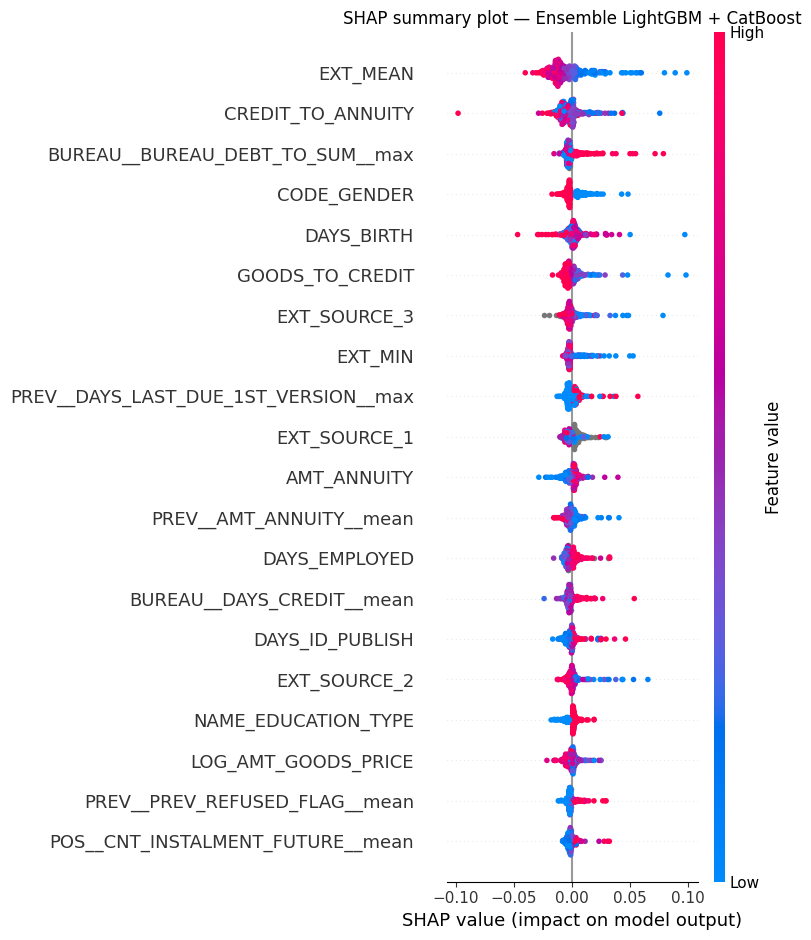

SHAP summary plot збережено: C:\programas\diploma\data\notebooks\shap_results\shap_ensemble_summary.png


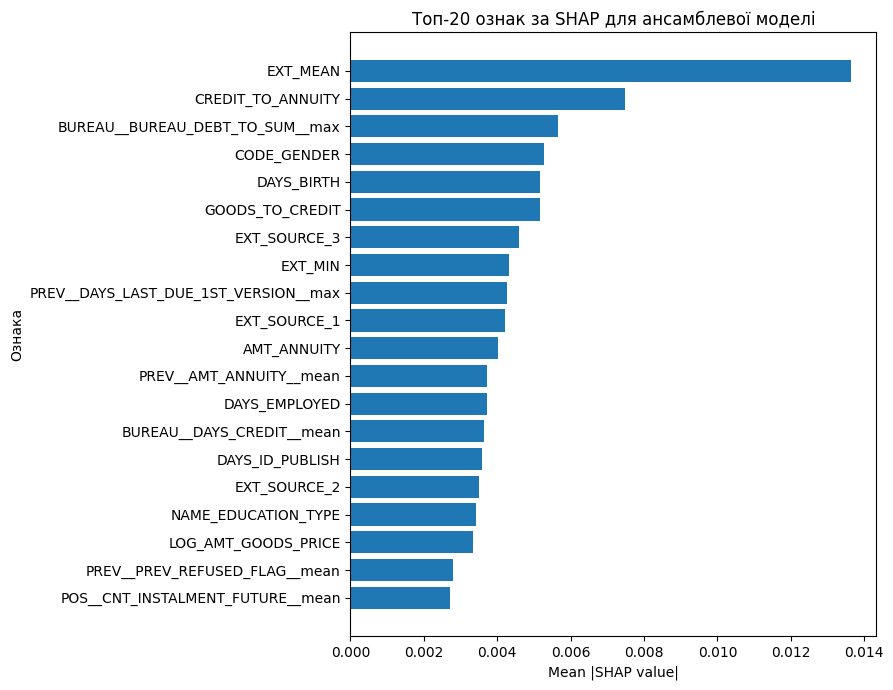

SHAP bar plot збережено: C:\programas\diploma\data\notebooks\shap_results\shap_ensemble_bar.png

Топ-25 ознак за SHAP для ансамблевої моделі


,Ознака,Mean |SHAP value|
1,EXT_MEAN,0.013651
2,CREDIT_TO_ANNUITY,0.007476
7,BUREAU__BUREAU_DEBT_TO_SUM__max,0.005657
12,CODE_GENDER,0.005270
3,DAYS_BIRTH,0.005166
9,GOODS_TO_CREDIT,0.005165
5,EXT_SOURCE_3,0.004601
4,EXT_MIN,0.004321
34,PREV__DAYS_LAST_DUE_1ST_VERSION__max,0.004260
8,EXT_SOURCE_1,0.004218



Формат для копіювання у Word:
Ознака	Mean |SHAP value|
EXT_MEAN	0,013651
CREDIT_TO_ANNUITY	0,007476
BUREAU__BUREAU_DEBT_TO_SUM__max	0,005657
CODE_GENDER	0,00527
DAYS_BIRTH	0,005166
GOODS_TO_CREDIT	0,005165
EXT_SOURCE_3	0,004601
EXT_MIN	0,004321
PREV__DAYS_LAST_DUE_1ST_VERSION__max	0,00426
EXT_SOURCE_1	0,004218
AMT_ANNUITY	0,004014
PREV__AMT_ANNUITY__mean	0,003723
DAYS_EMPLOYED	0,003721
BUREAU__DAYS_CREDIT__mean	0,003628
DAYS_ID_PUBLISH	0,003576
EXT_SOURCE_2	0,003517
NAME_EDUCATION_TYPE	0,003426
LOG_AMT_GOODS_PRICE	0,003351
PREV__PREV_REFUSED_FLAG__mean	0,002785
POS__CNT_INSTALMENT_FUTURE__mean	0,002719
NAME_FAMILY_STATUS	0,002687
EXT_MAX	0,002612
INST_CNT	0,002612
INST_DPD_TREND	0,002502
POS__MONTHS_BALANCE__min	0,002502

Таблиця SHAP importance збережена:
C:\programas\diploma\data\notebooks\shap_results\shap_ensemble_importance.csv


In [ ]:
import json
import pickle
import warnings
from pathlib import Path

import joblib
import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
from catboost import CatBoostClassifier
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.model_selection import train_test_split

try:
    from IPython.display import display
except ImportError:
    display = print


warnings.filterwarnings("ignore")


# БЛОК КОНФІГУРАЦІЇ
# Тут визначаються всі шляхи до файлів і гіперпараметри, що використовуються
# протягом усього скрипту. Змінювати лише ці константи для адаптації під новий
# проєкт — решта коду підхопить зміни автоматично.


# Основні шляхи до підготовленого датасету, моделей і папки для результатів SHAP
DATA_PATH = Path(r"C:\programas\diploma\data\data_processed")
MODEL_SEARCH_ROOT = Path(r"C:\programas\diploma")
TRAIN_FILE = DATA_PATH / "final_train_clean_top200.csv"
SAVE_DIR = Path(r"C:\programas\diploma\data\notebooks\shap_results")

# Назва цільової змінної
TARGET_COL = "TARGET"

# Початкові ваги фінального ансамблю LightGBM + CatBoost
# Підібрані під час оптимізації ансамблю на валідаційній вибірці;
# якщо знайдено файл ensemble_weights.json — ці значення будуть перезаписані
W_LGB = 0.578
W_CAT = 0.422

# Розміри вибірок для розрахунку SHAP
# BACKGROUND_SIZE — кількість спостережень для базового розподілу масктера;
# EXPLAIN_SIZE    — кількість спостережень, для яких будуть розраховані SHAP-значення
BACKGROUND_SIZE = 50
EXPLAIN_SIZE = 300


# ДОПОМІЖНІ ФУНКЦІЇ — ПІДГОТОВКА СЕРЕДОВИЩА ТА ЗАВАНТАЖЕННЯ ДАНИХ

# Функція створює папку для збереження результатів SHAP
# Використовує parents=True, 
# щоб створити всі проміжні підпапки за потреби;
# exist_ok=True запобігає помилці, якщо папка вже існує
def create_output_folder():
    SAVE_DIR.mkdir(parents=True, exist_ok=True)
    return SAVE_DIR


# Функція зчитує підготовлений датасет для моделювання
# Перевіряє наявність файлу та 
# цільової змінної перед поверненням X і y,
# щоб одразу надати зрозуміле 
# повідомлення про помилку замість трейсбеку
def load_training_data():
    if not TRAIN_FILE.exists():
        raise FileNotFoundError(f"Файл не знайдено: {TRAIN_FILE}")

    train = pd.read_csv(TRAIN_FILE)

    if TARGET_COL not in train.columns:
        raise ValueError("У датасеті немає цільової змінної TARGET.")

    # Відокремлюємо ознаки від цільової змінної
    X = train.drop(columns=[TARGET_COL])
    y = train[TARGET_COL]

    print("Дані завантажено успішно")
    print("Train shape:", train.shape)
    print("X shape:", X.shape)
    print("Розподіл цільової змінної:")
    print(y.value_counts(normalize=True))

    return X, y



# БЛОК ПОШУКУ ФАЙЛІВ МОДЕЛЕЙ
# Файли моделей шукаються рекурсивно 
# по всьому дереву MODEL_SEARCH_ROOT,
# тому розташування збережених 
# артефактів не має значення — скрипт знайде їх
# автоматично за розширенням та іменем
# Функція шукає файли моделей або ваг за заданими шаблонами
# root    — коренева папка для рекурсивного пошуку
# patterns — список glob-шаблонів (наприклад, "*.pkl", "*lgb*.txt")
# Повертає список унікальних Path-об'єктів без дублікатів
def find_files_by_patterns(root, patterns):
    found = []

    if root.exists():
        for pattern in patterns:
            found.extend(list(root.rglob(pattern)))

    # Видалення дублікатів зі списку знайдених файлів
    # dict.fromkeys зберігає порядок і при цьому прибирає повтори
    found = list(dict.fromkeys(found))

    return found


# Функція знаходить можливі файли 
# LightGBM, CatBoost і ваг ансамблю
# Шукає окремо для кожного типу, 
# щоб зручніше звітувати про знахідки
# та незалежно обробляти відсутність будь-якого з артефактів
def find_model_files():
    # Шаблони для LightGBM: підтримуються pickle, joblib і нативний .txt формат
    lgb_candidates = find_files_by_patterns(
        MODEL_SEARCH_ROOT,
        [
            "lightgbm_model.pkl",
            "lgb_model.pkl",
            "*lightgbm*.pkl",
            "*lgb*.pkl",
            "*lightgbm*.joblib",
            "*lgb*.joblib",
            "*lightgbm*.txt",
            "*lgb*.txt"
        ]
    )

    # Шаблони для CatBoost: використовує власний бінарний формат .cbm
    cat_candidates = find_files_by_patterns(
        MODEL_SEARCH_ROOT,
        [
            "catboost_model.cbm",
            "cat_model.cbm",
            "*catboost*.cbm",
            "*cat*.cbm"
        ]
    )

    # Шаблони для JSON-файлу з вагами ансамблю
    weights_candidates = find_files_by_patterns(
        MODEL_SEARCH_ROOT,
        [
            "ensemble_weights.json",
            "*ensemble*weights*.json",
            "*weights*.json"
        ]
    )

    print("\nЗнайдені кандидати LightGBM:")
    for file in lgb_candidates:
        print(file, "| size:", file.stat().st_size)

    print("\nЗнайдені кандидати CatBoost:")
    for file in cat_candidates:
        print(file, "| size:", file.stat().st_size)

    print("\nЗнайдені кандидати weights:")
    for file in weights_candidates:
        print(file, "| size:", file.stat().st_size)

    return lgb_candidates, cat_candidates, weights_candidates


# БЛОК ЗАВАНТАЖЕННЯ МОДЕЛЕЙ ТА ВАГИ АНСАМБЛЮ
# Функція завантажує ваги ансамблю з JSON-файлу,
# якщо такий файл знайдено
# Якщо файл відсутній або пошкоджений — функція мовчки повертає константи
# W_LGB та W_CAT, визначені на початку скрипту
def load_ensemble_weights(weights_candidates):
    w_lgb = W_LGB
    w_cat = W_CAT

    if len(weights_candidates) > 0:
        try:
            with open(weights_candidates[0], "r", encoding="utf-8") as file:
                weights = json.load(file)

            # dict.get з дефолтним значенням — безпечне читання ключів
            w_lgb = weights.get("lightgbm", w_lgb)
            w_cat = weights.get("catboost", w_cat)

            print("\nВаги ансамблю завантажено з файлу:")
            print(weights_candidates[0])
        except Exception as error:
            print("\nНе вдалося завантажити файл ваг. Використано стандартні ваги.")
            print(type(error).__name__, error)

    print("\nВаги ансамблю:")
    print("LightGBM:", w_lgb)
    print("CatBoost:", w_cat)

    return w_lgb, w_cat


# Функція завантажує модель 
# LightGBM з можливих форматів файлу
# Порядок спроб: .txt (нативний Booster) → pickle → joblib → Booster повторно
# Кожна невдала спроба логується, 
# але не зупиняє виконання — перехід до наступного формату
def load_lightgbm_candidate(path):
    path = Path(path)

    # Для файлу .txt використовується нативний формат LightGBM Booster
    if path.suffix.lower() == ".txt":
        try:
            model = lgb.Booster(model_file=str(path))
            print("LightGBM завантажено як Booster:", path)
            return model
        except Exception as error:
            print("Не вдалося завантажити .txt як Booster:", type(error).__name__, error)

    # Спроба завантаження моделі через pickle
    try:
        with open(path, "rb") as file:
            model = pickle.load(file)

        print("LightGBM завантажено через pickle:", path)
        return model
    except Exception as error:
        print("pickle не спрацював для", path.name, ":", type(error).__name__, error)

    # Спроба завантаження моделі через joblib
    # joblib ефективніший за 
    # pickle для великих numpy-масивів
    try:
        model = joblib.load(path)
        print("LightGBM завантажено через joblib:", path)
        return model
    except Exception as error:
        print("joblib не спрацював для", path.name, ":", type(error).__name__, error)

    # Додаткова спроба завантажити файл як LightGBM Booster
    # Актуально для .pkl-файлів, що 
    # насправді містять серіалізований Booster
    try:
        model = lgb.Booster(model_file=str(path))
        print("LightGBM завантажено як Booster:", path)
        return model
    except Exception as error:
        print("Booster не спрацював для", path.name, ":", type(error).__name__, error)

    return None


# Функція завантажує модель CatBoost з файлу .cbm
# CatBoost має власний бінарний 
# формат — завантаження лише через рідний API
def load_catboost_candidate(path):
    path = Path(path)

    try:
        model = CatBoostClassifier()
        model.load_model(str(path))

        print("CatBoost завантажено:", path)
        return model
    except Exception as error:
        print("CatBoost не спрацював для", path.name, ":", type(error).__name__, error)

    return None



# БЛОК ПРОГНОЗУВАННЯ — УНІФІКОВАНИЙ ІНТЕРФЕЙС
# Окремі обгортки для кожної моделі дозволяють ансамблевій функції не знати
# про внутрішні відмінності API між LightGBM Booster і sklearn-сумісними моделями


# Функція повертає ймовірність 
# дефолту для моделі LightGBM
# LGBMClassifier має predict_proba, 
# а lgb.Booster — лише predict;
# функція автоматично обирає 
# правильний метод залежно від типу об'єкта
def predict_lgb(model, X_input):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X_input)[:, 1]

    return model.predict(X_input)


# Функція повертає ймовірність 
# дефолту для моделі CatBoost
# CatBoostClassifier завжди 
# підтримує predict_proba, тому виклик прямий
def predict_cat(model, X_input):
    return model.predict_proba(X_input)[:, 1]


# Функція перевіряє, чи модель може 
# сформувати прогноз для поточного набору ознак
# Запускається на малій вибірці
# для швидкої валідації без зайвих витрат;
# повертає True лише якщо прогноз 
# є 1D-масивом правильної довжини
def test_model_prediction(model, model_type, X_sample):
    try:
        if model_type == "lgb":
            prediction = predict_lgb(model, X_sample)
        elif model_type == "cat":
            prediction = predict_cat(model, X_sample)
        else:
            return False

        prediction = np.asarray(prediction)

        # Перевіряємо розмірність і довжину результату
        if prediction.ndim != 1:
            return False

        if len(prediction) != len(X_sample):
            return False

        return True

    except Exception as error:
        print(f"Модель {model_type} не пройшла тест прогнозу:", type(error).__name__, error)

    return False



# БЛОК ВИБОРУ МОДЕЛЕЙ З КАНДИДАТІВ

# Функція вибирає першу коректну 
# модель LightGBM із кандидатів
# Ітерується по всіх знайдених файлах 
# і повертає першу модель, яка пройшла тест;
# якщо жодна не підходить — повертає 
# None, і далі запускається перенавчання
def choose_lightgbm_model(lgb_candidates, X):
    for candidate in lgb_candidates:
        model = load_lightgbm_candidate(candidate)

        if model is not None and test_model_prediction(model, "lgb", X.iloc[:10]):
            print("Обрано LightGBM модель:", candidate)
            return model

        print("Файл знайдено, але модель не підходить для поточного X:", candidate)

    print("\nLightGBM не вдалося завантажити. Модель буде перенавчено.")

    return None


# Функція вибирає першу коректну 
# модель CatBoost із кандидатів
# Логіка аналогічна choose_lightgbm_model — 
# уніфікований підхід для обох бустингів
def choose_catboost_model(cat_candidates, X):
    for candidate in cat_candidates:
        model = load_catboost_candidate(candidate)

        if model is not None and test_model_prediction(model, "cat", X.iloc[:10]):
            print("Обрано CatBoost модель:", candidate)
            return model

        print("Файл знайдено, але модель не підходить для поточного X:", candidate)

    print("\nCatBoost не вдалося завантажити. Модель буде перенавчено.")

    return None


# БЛОК ПЕРЕНАВЧАННЯ МОДЕЛЕЙ (FALLBACK)
# Використовується лише якщо збережені 
# артефакти не знайдено або пошкоджені;
# гіперпараметри відповідають фінальним 
# значенням після підбору на конкурсі

# Функція навчає LightGBM, якщо 
# збережену модель не вдалося завантажити
# early_stopping зупиняє навчання 
# при відсутності покращення протягом 300 раундів,
# що захищає від перенавчання і зайвого часу виконання
def train_lightgbm(X_train, y_train, X_valid, y_valid):
    model = lgb.LGBMClassifier(
        n_estimators=8000,
        learning_rate=0.015,
        num_leaves=96,
        min_child_samples=80,
        subsample=0.75,
        subsample_freq=1,
        colsample_bytree=0.75,
        reg_lambda=4.0,
        reg_alpha=1.0,
        objective="binary",
        n_jobs=-1,
        random_state=42
    )

    model.fit(
        X_train,
        y_train,
        eval_set=[(X_valid, y_valid)],
        eval_metric="auc",
        callbacks=[
            lgb.early_stopping(300, verbose=False)
        ]
    )

    prediction = model.predict_proba(X_valid)[:, 1]

    # Виводимо обидві метрики: ROC-AUC і PR-AUC (остання важливіша при дисбалансі класів)
    print("LightGBM ROC-AUC valid:", roc_auc_score(y_valid, prediction))
    print("LightGBM PR-AUC valid :", average_precision_score(y_valid, prediction))

    return model


# Функція навчає CatBoost, якщо 
# збережену модель не вдалося завантажити
# verbose=False прибирає детальний 
# лог CatBoost, залишаючи тільки підсумкові метрики
def train_catboost(X_train, y_train, X_valid, y_valid):
    model = CatBoostClassifier(
        iterations=6000,
        learning_rate=0.02,
        depth=6,
        l2_leaf_reg=8,
        loss_function="Logloss",
        eval_metric="AUC",
        random_seed=42,
        verbose=False
    )

    model.fit(
        X_train,
        y_train,
        eval_set=(X_valid, y_valid),
        early_stopping_rounds=300,
        verbose=False
    )

    prediction = model.predict_proba(X_valid)[:, 1]

    print("CatBoost ROC-AUC valid:", roc_auc_score(y_valid, prediction))
    print("CatBoost PR-AUC valid :", average_precision_score(y_valid, prediction))

    return model


# Функція перенавчає ті моделі, 
# які не були завантажені з файлів
# Якщо обидві моделі завантажились 
# успішно — функція одразу повертає їх без змін,
# уникаючи зайвого train_test_split і витрат часу
def train_missing_models(lgb_model, cat_model, X, y):
    need_train_lgb = lgb_model is None
    need_train_cat = cat_model is None

    if not need_train_lgb and not need_train_cat:
        return lgb_model, cat_model

    print("\nПочинається перенавчання відсутніх моделей.")

    # Стратифікований поділ зберігає пропорцію класів у train і valid
    X_train, X_valid, y_train, y_valid = train_test_split(
        X,
        y,
        test_size=0.2,
        stratify=y,
        random_state=42
    )

    if need_train_lgb:
        print("\nНавчання LightGBM.")
        lgb_model = train_lightgbm(X_train, y_train, X_valid, y_valid)

    if need_train_cat:
        print("\nНавчання CatBoost.")
        cat_model = train_catboost(X_train, y_train, X_valid, y_valid)

    return lgb_model, cat_model


# БЛОК ПОБУДОВИ АНСАМБЛЮ
# Ансамбль реалізований як замикання (closure): внутрішня функція зберігає
# посилання на моделі, колонки і ваги, не вимагаючи глобальних змінних

# Функція створює прогноз фінального ансамблю LightGBM + CatBoost
# Повертає функцію-замикання, яку 
# можна передати безпосередньо в shap.Explainer;
# конвертація вхідних даних у 
# DataFrame гарантує правильний порядок ознак
def make_ensemble_predict_function(lgb_model, cat_model, X_columns, w_lgb, w_cat):
    def ensemble_predict_proba(X_input):
        # Вхідні дані переводяться у DataFrame з правильним порядком ознак
        # SHAP передає numpy-масив, тому потрібне явне відновлення назв колонок
        X_input = pd.DataFrame(X_input, columns=X_columns)

        pred_lgb = predict_lgb(lgb_model, X_input)
        pred_cat = predict_cat(cat_model, X_input)

        # Зважена сума прогнозів — лінійна комбінація ймовірностей
        pred_ensemble = w_lgb * pred_lgb + w_cat * pred_cat

        return pred_ensemble

    return ensemble_predict_proba


# БЛОК SHAP — ПІДГОТОВКА ВИБІРОК І РОЗРАХУНОК ЗНАЧЕНЬ

# Функція формує вибірки для фону SHAP і для пояснення прогнозів
# Фонова вибірка (background) описує базовий розподіл ознак для masker;
# вибірка для пояснень (explain) — спостереження, 
# для яких обчислюються SHAP-значення
def prepare_shap_samples(X):
    X_background = X.sample(
        n=min(BACKGROUND_SIZE, len(X)),
        random_state=42
    )

    X_explain = X.sample(
        n=min(EXPLAIN_SIZE, len(X)),
        random_state=123
    )

    print("\nSHAP background shape:", X_background.shape)
    print("SHAP explain shape   :", X_explain.shape)

    return X_background, X_explain


# Функція розраховує SHAP-значення для ансамблевої моделі
# Використовується алгоритм "permutation" — модель-незалежний підхід,
# що підходить для будь-якої чорної скриньки (в т.ч. ансамблю);
# max_evals = 2 * p + 1 — мінімально необхідна кількість оцінок за формулою SHAP
def calculate_shap_values(ensemble_predict_proba, X_background, X_explain):
    print("\nПочинається розрахунок SHAP для ансамблевої моделі.")
    print("Розрахунок може зайняти декілька хвилин.")

    # Independent masker розглядає 
    # ознаки як незалежні при маскуванні —
    # підходить для tabular-даних 
    # без сильних кореляцій між ознаками
    masker = shap.maskers.Independent(X_background)

    explainer = shap.Explainer(
        ensemble_predict_proba,
        masker,
        algorithm="permutation"
    )

    # Кількість оцінювань має бути не меншою за 2 * кількість ознак + 1
    max_evals = 2 * X_explain.shape[1] + 1

    shap_values = explainer(
        X_explain,
        max_evals=max_evals
    )

    print("SHAP для ансамблю розраховано успішно.")

    return shap_values


# БЛОК ВІЗУАЛІЗАЦІЇ ТА ЗБЕРЕЖЕННЯ РЕЗУЛЬТАТІВ

# Функція будує та зберігає SHAP summary plot
# Summary plot показує розподіл 
# SHAP-значень для кожної ознаки:
# колір — значення ознаки (червоний = велике),
# вісь X — вплив на прогноз
def save_shap_summary_plot(shap_values, X_explain, save_dir):
    plt.figure(figsize=(10, 7))

    shap.summary_plot(
        shap_values.values,
        X_explain,
        max_display=20,
        show=False
    )

    plt.title("SHAP summary plot — Ensemble LightGBM + CatBoost", fontsize=12)
    plt.tight_layout()

    summary_path = save_dir / "shap_ensemble_summary.png"
    # dpi=300 забезпечує якість, достатню для публікації у дипломній роботі
    plt.savefig(summary_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("SHAP summary plot збережено:", summary_path)


# Функція формує таблицю важливості 
# ознак за середнім абсолютним SHAP-значенням
# Mean |SHAP| — найбільш поширена 
# агрегована міра важливості в SHAP-аналізі;
# відображає середній внесок 
# ознаки у відхилення прогнозу від базового значення
def get_shap_importance_table(shap_values, X_explain):
    # Осі shap_values.values: (n_samples, n_features) → усереднення по рядках
    mean_abs_shap = np.abs(shap_values.values).mean(axis=0)

    shap_importance = pd.DataFrame({
        "Ознака": X_explain.columns,
        "Mean |SHAP value|": mean_abs_shap
    })

    shap_importance = shap_importance.sort_values(
        by="Mean |SHAP value|",
        ascending=False
    )

    return shap_importance


# Функція будує та зберігає bar plot для топ-20 ознак за SHAP
# Горизонтальний bar plot зручніший 
# за вертикальний при довгих назвах ознак
def save_shap_bar_plot(shap_importance, save_dir):
    # sort ascending=True, щоб найважливіша ознака опинилась зверху графіку
    top20 = shap_importance.head(20).sort_values("Mean |SHAP value|")

    plt.figure(figsize=(9, 7))
    plt.barh(
        top20["Ознака"],
        top20["Mean |SHAP value|"]
    )

    plt.xlabel("Mean |SHAP value|")
    plt.ylabel("Ознака")
    plt.title("Топ-20 ознак за SHAP для ансамблевої моделі")
    plt.tight_layout()

    bar_path = save_dir / "shap_ensemble_bar.png"
    plt.savefig(bar_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("SHAP bar plot збережено:", bar_path)


# Функція виводить таблицю SHAP у форматії
# Значення округлюються до 6 знаків і крапка замінюється на кому —
# стандарт для числових даних   
def print_word_format(shap_importance):
    print("\nФормат для копіювання у Word:")
    print("Ознака\tMean |SHAP value|")

    for _, row in shap_importance.head(25).iterrows():
        value = str(round(row["Mean |SHAP value|"], 6)).replace(".", ",")
        print(f"{row['Ознака']}\t{value}")


# Функція зберігає таблицю важливості ознак за SHAP у CSV-файл
# Кодування utf-8-sig додає BOM-маркер, 
# необхідний для коректного відображення
# кирилиці при відкритті CSV у Microsoft Excel на Windows
def save_shap_importance_table(shap_importance, save_dir):
    importance_path = save_dir / "shap_ensemble_importance.csv"

    shap_importance.to_csv(
        importance_path,
        index=False,
        encoding="utf-8-sig"
    )

    print("\nТаблиця SHAP importance збережена:")
    print(importance_path)


# ГОЛОВНА ФУНКЦІЯ — ТОЧКА ВХОДУ
# main() об'єднує всі блоки в єдиний
# пайплайн і викликається в кінці скрипту;
# такий підхід дозволяє імпортувати окремі функції з інших модулів без
# автоматичного запуску всього пайплайну
# Функція запускає весь процес SHAP-інтерпретації фінальної моделі
def main():
    # Крок 1: підготовка папки для збереження результатів
    save_dir = create_output_folder()

    # Крок 2: завантаження даних і виділення ознак та цільової змінної
    X, y = load_training_data()

    # Крок 3: пошук файлів моделей і завантаження ваг ансамблю
    lgb_candidates, cat_candidates, weights_candidates = find_model_files()
    w_lgb, w_cat = load_ensemble_weights(weights_candidates)

    # Крок 4: завантаження або перенавчання LightGBM і CatBoost
    lgb_model = choose_lightgbm_model(lgb_candidates, X)
    cat_model = choose_catboost_model(cat_candidates, X)

    lgb_model, cat_model = train_missing_models(lgb_model, cat_model, X, y)

    # Крок 5: побудова функції-замикання для ансамблевого прогнозування
    ensemble_predict_proba = make_ensemble_predict_function(
        lgb_model=lgb_model,
        cat_model=cat_model,
        X_columns=X.columns,
        w_lgb=w_lgb,
        w_cat=w_cat
    )

    # Швидка перевірка: переконуємось, що ансамбль повертає коректні ймовірності
    example_prediction = ensemble_predict_proba(X.iloc[:10])
    print("\nПриклад прогнозів ансамблю:")
    print(example_prediction)

    # Крок 6: формування вибірок для SHAP
    X_background, X_explain = prepare_shap_samples(X)

    # Крок 7: розрахунок SHAP-значень (найтриваліший крок)
    shap_values = calculate_shap_values(
        ensemble_predict_proba,
        X_background,
        X_explain
    )

    # Крок 8: побудова та збереження summary plot
    save_shap_summary_plot(shap_values, X_explain, save_dir)

    # Крок 9: формування таблиці важливості та bar plot
    shap_importance = get_shap_importance_table(shap_values, X_explain)

    save_shap_bar_plot(shap_importance, save_dir)

    print("\nТоп-25 ознак за SHAP для ансамблевої моделі:")
    display(shap_importance.head(25).round(6))

    # Крок 10: виведення у форматі для Word і збереження CSV
    print_word_format(shap_importance)

    save_shap_importance_table(shap_importance, save_dir)

    print("\nSHAP-інтерпретацію завершено.")


main()